# Robot Navigation Action Classification

Programming in Python Final-Term Group Project

## 1. Dataset and Problem Context

The goal of this project is to classify the navigation action of a mobile robot using ultrasonic sensor readings.

Each observation contains readings from 24 ultrasonic sensors positioned around the robot. The target variable represents one of four navigation actions:

- Move-Forward
- Slight-Right-Turn
- Sharp-Right-Turn
- Slight-Left-Turn

The dataset contains 5,456 observations.

Source: UCI Machine Learning Repository, Wall-Following Robot Navigation Data.

DOI: 10.24432/C57C8W

### Data Collection Context

The dataset is sequential. The SCITOS G5 robot navigated the room clockwise for four rounds, and the ultrasonic sensor readings were sampled at approximately 9 observations per second.

Because consecutive observations were collected close together in time, the sequential nature of the data should be considered later when designing the training, validation, and test split.

### Project Objective and Success Criteria

Each row represents one sequential robot state containing 24 ultrasonic sensor readings. The prediction target is the navigation action associated with that state.

The project is relevant to researchers and developers studying sensor-based mobile-robot navigation.

A useful model should perform substantially better than the majority-class baseline and should classify all four navigation actions effectively rather than achieving high accuracy only on the most common classes. Therefore, Macro F1 and class-wise Precision, Recall, and F1 are considered together with overall Accuracy.

### Privacy and Ethical Considerations

The dataset contains robot sensor measurements and navigation-action labels rather than personal or sensitive human information, so there are no direct personal-privacy concerns in the dataset.

However, model predictions could become safety-relevant if used to control a physical robot. Therefore, the classifier is treated as an experimental prediction model and should not be considered a complete safety-critical navigation controller without additional real-world testing and safety mechanisms.

Dataset license: CC BY 4.0.

## 2. Import Libraries


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import importlib.metadata as metadata


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from time import perf_counter
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")




## 3. Load the Dataset

In [2]:
sensor_columns = [
    "US1", "US2", "US3", "US4", "US5", "US6",
    "US7", "US8", "US9", "US10", "US11", "US12",
    "US13", "US14", "US15", "US16", "US17", "US18",
    "US19", "US20", "US21", "US22", "US23", "US24"
]

column_names = sensor_columns + ["Class"]

print(column_names)

['US1', 'US2', 'US3', 'US4', 'US5', 'US6', 'US7', 'US8', 'US9', 'US10', 'US11', 'US12', 'US13', 'US14', 'US15', 'US16', 'US17', 'US18', 'US19', 'US20', 'US21', 'US22', 'US23', 'US24', 'Class']


In [3]:
df_raw = pd.read_csv(
    "../data/raw/sensor_readings_24.data",
    sep=",",
    header=None,
    names=column_names
)

In [4]:
# Keep the raw DataFrame unchanged and work on a copy
df = df_raw.copy()

## 4. Initial Dataset Inspection

In [5]:
df.head(10)

,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US16,US17,US18,US19,US20,US21,US22,US23,US24,Class
0,0.438,0.498,3.625,3.645,5.0,2.918,5.000,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.0,2.918,5.000,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.0,2.918,5.000,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
3,0.437,0.501,3.625,3.626,5.0,2.918,5.000,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
4,0.438,0.498,3.626,3.629,5.0,2.918,5.000,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn
5,0.439,0.498,3.626,3.629,5.0,2.918,5.000,2.633,2.334,2.645,...,0.589,0.502,0.493,0.504,0.446,0.431,0.444,0.444,0.430,Slight-Right-Turn
6,0.440,5.000,3.627,3.628,5.0,2.919,3.028,2.346,2.330,2.638,...,0.588,0.501,0.492,0.504,0.451,0.433,0.446,0.444,0.432,Slight-Right-Turn
7,0.444,5.021,3.631,3.634,5.0,2.919,5.000,2.626,2.327,2.638,...,0.595,0.500,0.491,0.503,0.453,0.436,0.448,0.444,0.436,Slight-Right-Turn
8,0.451,5.025,3.635,3.639,5.0,2.920,3.027,2.620,2.323,2.632,...,0.595,0.499,0.491,0.502,0.457,0.440,0.453,0.454,0.442,Sharp-Right-Turn
9,0.458,5.022,3.640,3.644,5.0,2.922,5.000,2.346,2.321,2.628,...,0.590,0.496,0.490,0.498,0.462,0.444,0.458,0.461,0.449,Sharp-Right-Turn


In [6]:
df.tail(7)

,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US16,US17,US18,US19,US20,US21,US22,US23,US24,Class
5449,1.646,3.925,3.958,2.771,2.756,2.337,2.439,1.127,1.785,1.077,...,0.674,0.662,0.672,0.753,5.000,1.026,5.0,5.0,1.594,Move-Forward
5450,0.911,3.939,3.976,2.775,2.763,2.573,2.436,1.106,1.781,1.059,...,0.667,0.655,0.665,1.591,5.000,1.035,5.0,5.0,5.000,Move-Forward
5451,0.910,5.000,3.997,2.785,2.770,2.572,2.433,1.087,1.772,1.040,...,0.660,0.648,0.657,0.686,5.000,1.045,5.0,5.0,1.562,Move-Forward
5452,0.926,5.000,4.015,2.792,2.777,2.571,1.768,1.071,1.762,1.021,...,0.652,0.640,0.649,1.593,1.616,1.058,5.0,5.0,1.085,Sharp-Right-Turn
5453,0.937,5.000,4.034,2.799,2.784,2.571,1.754,1.053,1.752,1.002,...,0.648,0.633,0.642,0.741,5.000,1.065,5.0,5.0,1.105,Sharp-Right-Turn
5454,0.945,4.052,4.052,2.809,2.791,2.441,1.757,1.034,1.743,0.983,...,0.641,0.626,0.635,0.754,5.000,1.076,5.0,5.0,1.118,Move-Forward
5455,0.950,4.066,5.000,2.819,2.798,2.570,2.422,1.016,1.739,0.964,...,0.635,0.618,0.628,0.776,5.000,1.083,5.0,5.0,1.168,Sharp-Right-Turn


In [7]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(list(df.columns))

Dataset shape: (5456, 25)

Column names:
['US1', 'US2', 'US3', 'US4', 'US5', 'US6', 'US7', 'US8', 'US9', 'US10', 'US11', 'US12', 'US13', 'US14', 'US15', 'US16', 'US17', 'US18', 'US19', 'US20', 'US21', 'US22', 'US23', 'US24', 'Class']


In [8]:
print(df.dtypes)

US1      float64
US2      float64
US3      float64
US4      float64
US5      float64
US6      float64
US7      float64
US8      float64
US9      float64
US10     float64
US11     float64
US12     float64
US13     float64
US14     float64
US15     float64
US16     float64
US17     float64
US18     float64
US19     float64
US20     float64
US21     float64
US22     float64
US23     float64
US24     float64
Class        str
dtype: object


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5456 entries, 0 to 5455
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   US1     5456 non-null   float64
 1   US2     5456 non-null   float64
 2   US3     5456 non-null   float64
 3   US4     5456 non-null   float64
 4   US5     5456 non-null   float64
 5   US6     5456 non-null   float64
 6   US7     5456 non-null   float64
 7   US8     5456 non-null   float64
 8   US9     5456 non-null   float64
 9   US10    5456 non-null   float64
 10  US11    5456 non-null   float64
 11  US12    5456 non-null   float64
 12  US13    5456 non-null   float64
 13  US14    5456 non-null   float64
 14  US15    5456 non-null   float64
 15  US16    5456 non-null   float64
 16  US17    5456 non-null   float64
 17  US18    5456 non-null   float64
 18  US19    5456 non-null   float64
 19  US20    5456 non-null   float64
 20  US21    5456 non-null   float64
 21  US22    5456 non-null   float64
 22  US23    545

## 5. Descriptive Statistics

In [10]:
df.describe()

,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US15,US16,US17,US18,US19,US20,US21,US22,US23,US24
count,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,...,5456.000000,5456.000000,5456.000000,5456.000000,5456.00000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000
mean,1.471617,2.327043,2.489347,2.796501,2.958552,2.893073,3.351113,2.540397,3.125621,2.832386,...,2.205772,1.202111,0.989831,0.910273,1.05811,1.076320,1.015923,1.778034,1.555045,1.578508
std,0.802801,1.410146,1.247435,1.309368,1.339225,1.282575,1.413692,1.111554,1.356965,1.307843,...,1.715435,1.098568,0.942075,0.889527,1.14463,1.141498,0.887439,1.571686,1.291447,1.150480
min,0.400000,0.437000,0.470000,0.833000,1.120000,1.114000,1.122000,0.859000,0.836000,0.810000,...,0.495000,0.424000,0.373000,0.354000,0.34000,0.355000,0.380000,0.370000,0.367000,0.377000
25%,0.921000,1.362000,1.538750,1.731000,1.774000,1.785750,1.930750,1.618000,1.799750,1.636000,...,0.860000,0.690000,0.581000,0.529750,0.52300,0.541750,0.567000,0.743000,0.792000,0.884000
50%,1.335000,1.904500,2.064000,2.458000,2.667000,2.682500,3.225500,2.172000,2.802000,2.679000,...,1.328500,0.803000,0.738000,0.685000,0.69100,0.693000,0.764000,1.030500,1.071000,1.289000
75%,1.814000,2.681500,2.739250,4.093500,4.314500,3.835250,5.000000,3.193000,5.000000,3.526250,...,4.436250,1.159000,0.913000,0.837000,0.85700,0.863000,1.002250,2.068250,1.559500,1.657250
max,5.000000,5.025000,5.029000,5.017000,5.000000,5.005000,5.008000,5.087000,5.000000,5.022000,...,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000


In [11]:
df.describe(include="all")

,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US16,US17,US18,US19,US20,US21,US22,US23,US24,Class
count,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,...,5456.000000,5456.000000,5456.000000,5456.00000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Move-Forward
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2205
mean,1.471617,2.327043,2.489347,2.796501,2.958552,2.893073,3.351113,2.540397,3.125621,2.832386,...,1.202111,0.989831,0.910273,1.05811,1.076320,1.015923,1.778034,1.555045,1.578508,NaN
std,0.802801,1.410146,1.247435,1.309368,1.339225,1.282575,1.413692,1.111554,1.356965,1.307843,...,1.098568,0.942075,0.889527,1.14463,1.141498,0.887439,1.571686,1.291447,1.150480,NaN
min,0.400000,0.437000,0.470000,0.833000,1.120000,1.114000,1.122000,0.859000,0.836000,0.810000,...,0.424000,0.373000,0.354000,0.34000,0.355000,0.380000,0.370000,0.367000,0.377000,NaN
25%,0.921000,1.362000,1.538750,1.731000,1.774000,1.785750,1.930750,1.618000,1.799750,1.636000,...,0.690000,0.581000,0.529750,0.52300,0.541750,0.567000,0.743000,0.792000,0.884000,NaN
50%,1.335000,1.904500,2.064000,2.458000,2.667000,2.682500,3.225500,2.172000,2.802000,2.679000,...,0.803000,0.738000,0.685000,0.69100,0.693000,0.764000,1.030500,1.071000,1.289000,NaN
75%,1.814000,2.681500,2.739250,4.093500,4.314500,3.835250,5.000000,3.193000,5.000000,3.526250,...,1.159000,0.913000,0.837000,0.85700,0.863000,1.002250,2.068250,1.559500,1.657250,NaN


## 6. Data Audit

In [12]:
missing_values = df.isna().sum()

print(missing_values)

US1      0
US2      0
US3      0
US4      0
US5      0
US6      0
US7      0
US8      0
US9      0
US10     0
US11     0
US12     0
US13     0
US14     0
US15     0
US16     0
US17     0
US18     0
US19     0
US20     0
US21     0
US22     0
US23     0
US24     0
Class    0
dtype: int64


In [13]:
print("Total missing values:", df.isna().sum().sum())

Total missing values: 0


In [14]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [15]:
print("Unique class labels:")
print(df["Class"].unique())

Unique class labels:
<StringArray>
['Slight-Right-Turn', 'Sharp-Right-Turn', 'Move-Forward', 'Slight-Left-Turn']
Length: 4, dtype: str


In [16]:
expected_classes = [
    "Move-Forward",
    "Slight-Right-Turn",
    "Sharp-Right-Turn",
    "Slight-Left-Turn"
]

assert df["Class"].isin(expected_classes).all()

print("All class labels are valid.")

All class labels are valid.


In [17]:
all_non_negative = (df[sensor_columns] >= 0).all().all()

print("All sensor readings are non-negative:", all_non_negative)

All sensor readings are non-negative: True


In [18]:
print("Minimum value for each sensor:")
print(df[sensor_columns].min())

print("\nMaximum value for each sensor:")
print(df[sensor_columns].max())

Minimum value for each sensor:
US1     0.400
US2     0.437
US3     0.470
US4     0.833
US5     1.120
US6     1.114
US7     1.122
US8     0.859
US9     0.836
US10    0.810
US11    0.783
US12    0.778
US13    0.770
US14    0.756
US15    0.495
US16    0.424
US17    0.373
US18    0.354
US19    0.340
US20    0.355
US21    0.380
US22    0.370
US23    0.367
US24    0.377
dtype: float64

Maximum value for each sensor:
US1     5.000
US2     5.025
US3     5.029
US4     5.017
US5     5.000
US6     5.005
US7     5.008
US8     5.087
US9     5.000
US10    5.022
US11    5.019
US12    5.000
US13    5.003
US14    5.000
US15    5.000
US16    5.000
US17    5.000
US18    5.000
US19    5.000
US20    5.000
US21    5.000
US22    5.000
US23    5.000
US24    5.000
dtype: float64


### Extreme-Value Inspection

In [19]:
sensor_values = df[sensor_columns].to_numpy()

percentile_5 = np.percentile(sensor_values, 5, axis=0)
percentile_95 = np.percentile(sensor_values, 95, axis=0)

print("5th percentile for each sensor:")
print(percentile_5)

print("\n95th percentile for each sensor:")
print(percentile_95)

5th percentile for each sensor:
[0.54875 0.643   1.309   1.362   1.392   1.36875 1.35875 1.281   1.35
 1.1845  0.883   0.828   0.82    0.797   0.765   0.532   0.485   0.46075
 0.457   0.45775 0.45875 0.474   0.48775 0.525  ]

95th percentile for each sensor:
[2.644   5.      5.      5.      5.      5.      5.      5.      5.
 5.      5.      5.      5.      5.      5.      5.      3.0125  2.43475
 5.      5.      2.629   5.      5.      5.     ]


The sensor minimums, maximums, and percentile values were inspected to identify unusually low or high readings. Some measurements occur near the upper end of the observed sensor range, but these values are not removed because there is no evidence that they are invalid observations.

### Cleaning Decision

The raw dataset is kept unchanged.

The audit checks missing values, duplicate observations, class labels, data types, and sensor-value ranges.

No missing-value imputation is required because no missing values were found. No duplicate removal is required because no duplicate rows were found. Sensor readings are not removed simply because they are relatively high or low, because no justified invalid maximum threshold is provided for the project.

Therefore, no observations are removed during this stage, and the working DataFrame preserves the original dataset.

## 7. Target Class Distribution

In [20]:
class_counts = df["Class"].value_counts()

print("Class counts:")
print(class_counts)

Class counts:
Class
Move-Forward         2205
Sharp-Right-Turn     2097
Slight-Right-Turn     826
Slight-Left-Turn      328
Name: count, dtype: int64


In [21]:
class_percentages = df["Class"].value_counts(normalize=True) * 100

print("Class percentages:")
print(class_percentages)

Class percentages:
Class
Move-Forward         40.414223
Sharp-Right-Turn     38.434751
Slight-Right-Turn    15.139296
Slight-Left-Turn      6.011730
Name: proportion, dtype: float64


## 8. Exploratory Data Analysis

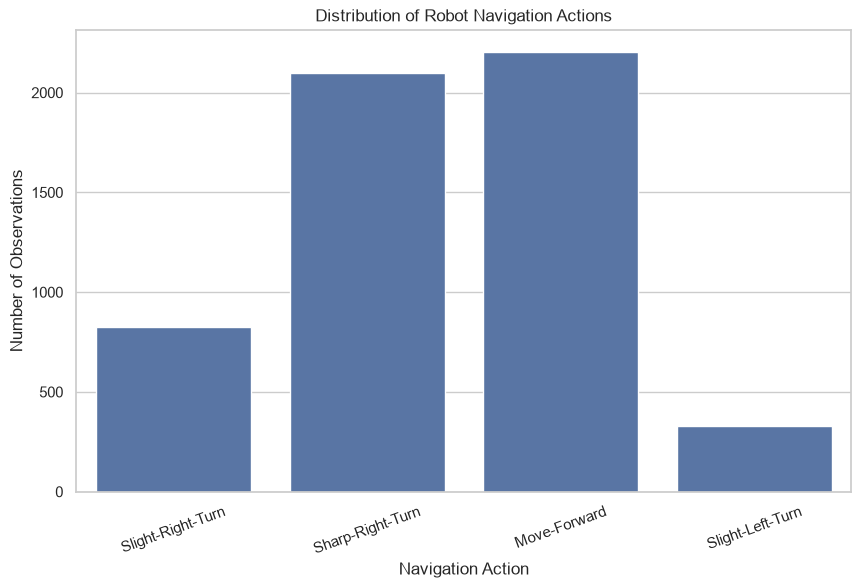

In [22]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Distribution of Robot Navigation Actions")
plt.xlabel("Navigation Action")
plt.ylabel("Number of Observations")
plt.xticks(rotation=20)

plt.show()

### Class Distribution Observation

The target classes are not equally represented. `Move-Forward` and `Sharp-Right-Turn` contain many more observations than `Slight-Left-Turn`. This class imbalance should be considered later when the machine-learning models are evaluated, so accuracy alone should not be used to judge performance.

### Representative Sensor Distributions

Four sensors from different positions around the robot are inspected to understand the distribution of ultrasonic distance readings.

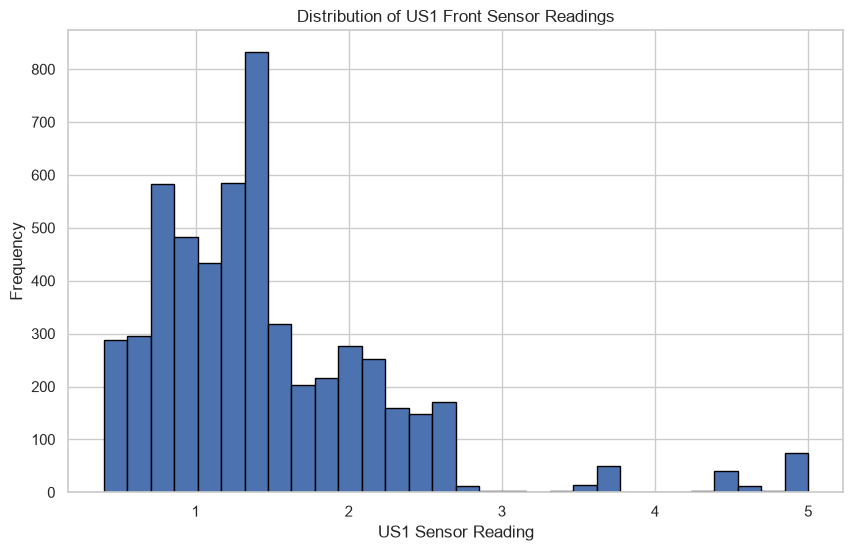

In [23]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["US1"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("US1 Sensor Reading")
plt.ylabel("Frequency")
plt.title("Distribution of US1 Front Sensor Readings")

plt.show()

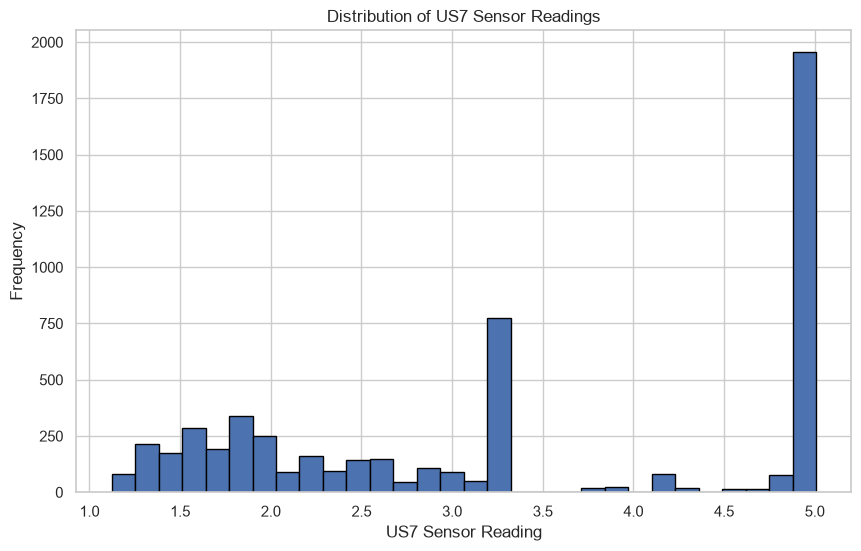

In [24]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["US7"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("US7 Sensor Reading")
plt.ylabel("Frequency")
plt.title("Distribution of US7 Sensor Readings")

plt.show()

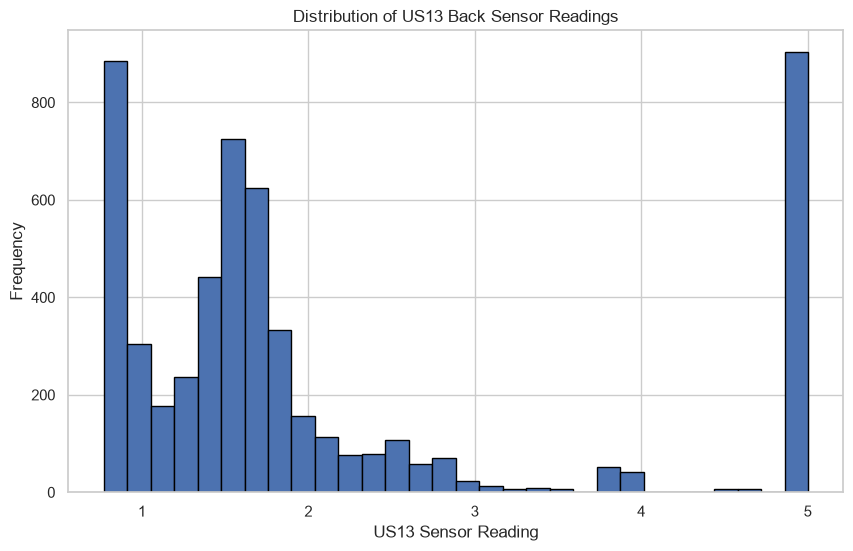

In [25]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["US13"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("US13 Sensor Reading")
plt.ylabel("Frequency")
plt.title("Distribution of US13 Back Sensor Readings")

plt.show()

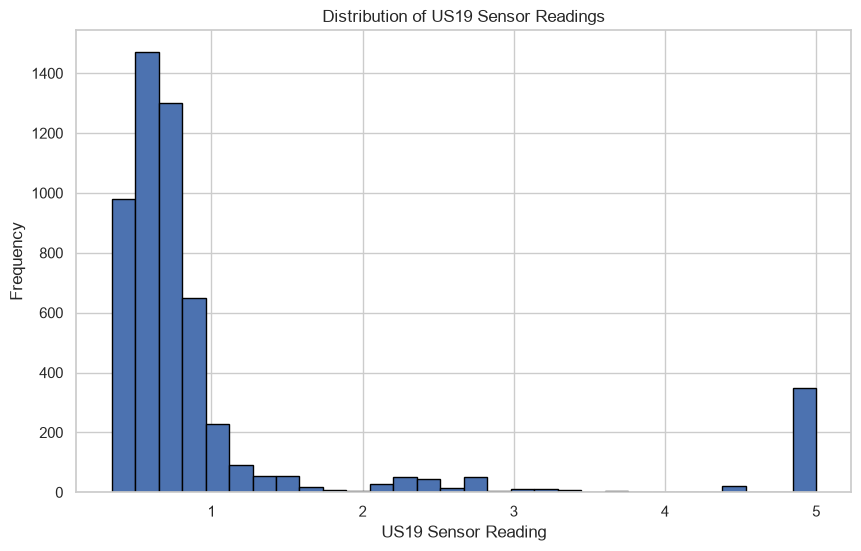

In [26]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["US19"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("US19 Sensor Reading")
plt.ylabel("Frequency")
plt.title("Distribution of US19 Sensor Readings")

plt.show()

### Sensor Distribution Observation

The sensor distributions are not identical across positions around the robot. Different sensors record different ranges and concentrations of distance values, which is expected because they measure obstacles from different directions.

### Front and Back Sensor Relationship

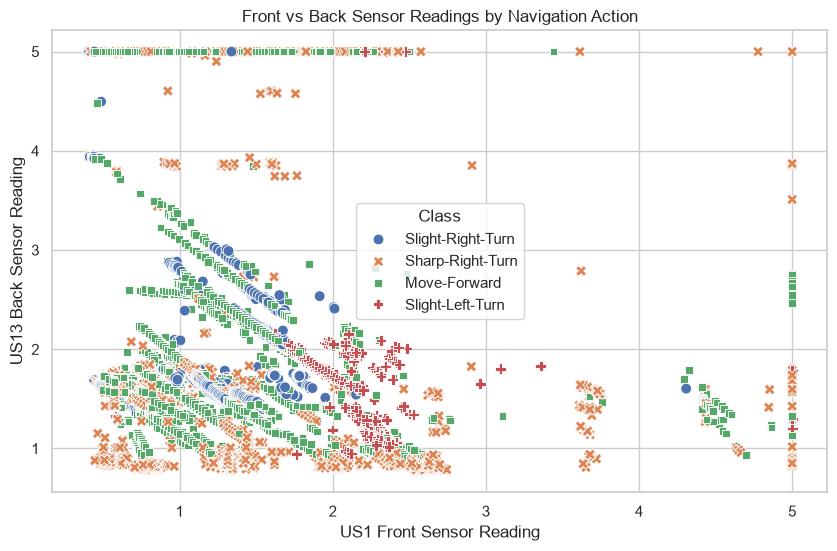

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="US1",
    y="US13",
    hue="Class",
    style="Class",
    s=60
)

plt.title("Front vs Back Sensor Readings by Navigation Action")
plt.xlabel("US1 Front Sensor Reading")
plt.ylabel("US13 Back Sensor Reading")

plt.show()

The scatterplot shows the relationship between the front sensor (`US1`) and the back sensor (`US13`) for the four navigation actions. The classes show some different patterns, but there is also overlap between several classes. This suggests that these two sensor readings alone may not be enough to clearly distinguish all four navigation actions.

### Side Sensor Relationship

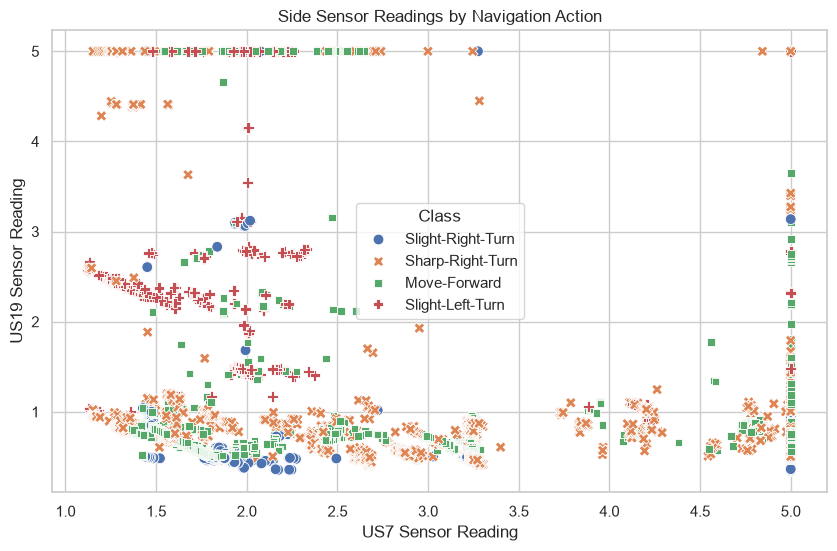

In [28]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="US7",
    y="US19",
    hue="Class",
    style="Class",
    s=60
)

plt.title("Side Sensor Readings by Navigation Action")
plt.xlabel("US7 Sensor Reading")
plt.ylabel("US19 Sensor Reading")

plt.show()

The side-sensor scatterplot shows that the navigation classes occupy different regions in some parts of the graph, but substantial overlap is also present. This suggests that the `US7` and `US19` readings alone are not sufficient to clearly distinguish all four navigation actions.

### Selected Multi-Sensor Relationships

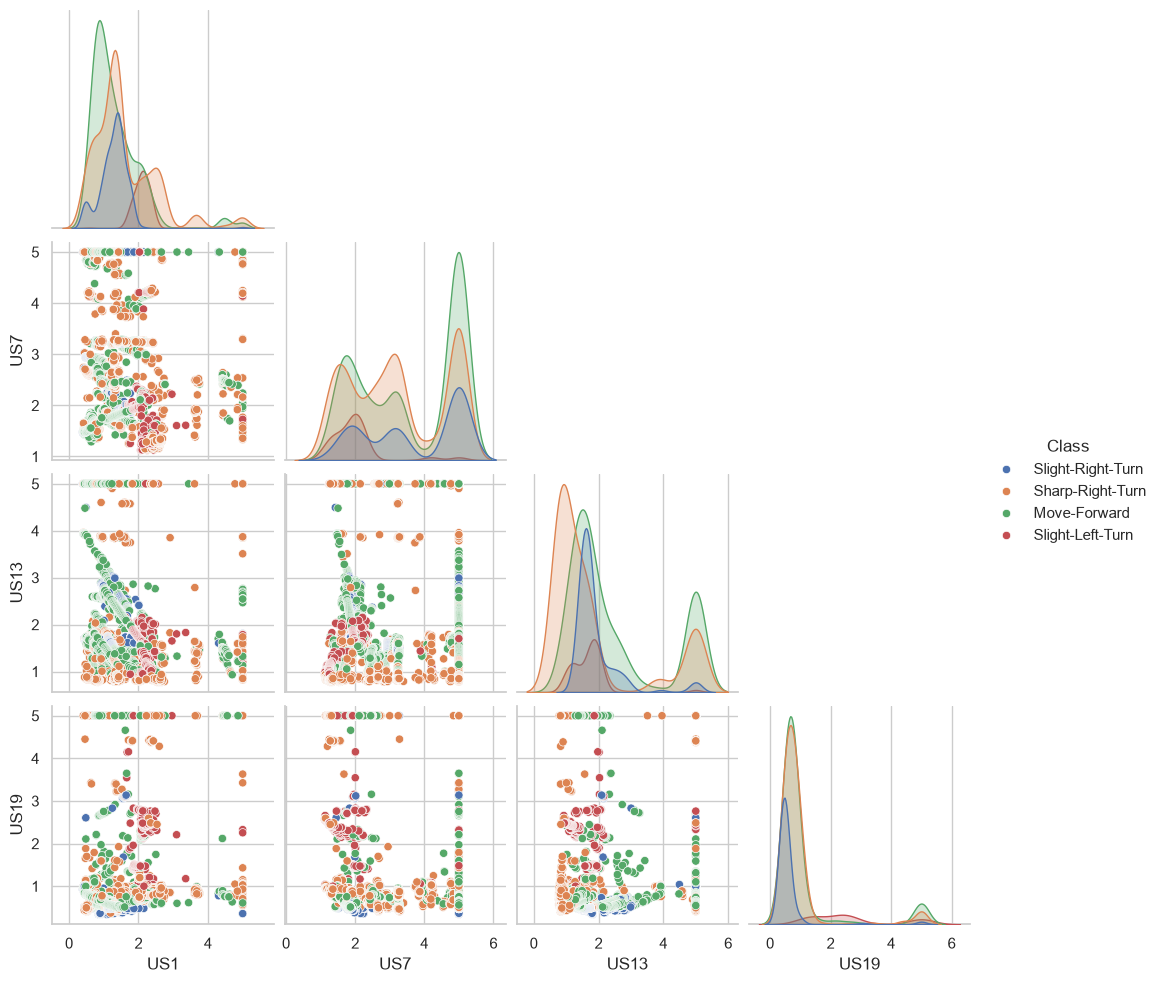

In [29]:
sns.pairplot(
    df,
    vars=[
        "US1",
        "US7",
        "US13",
        "US19"
    ],
    hue="Class",
    corner=True
)

plt.show()

The pairplot compares four representative sensors positioned around different parts of the robot. Some navigation classes show different concentration patterns across the selected sensor combinations, but considerable overlap remains. This indicates that using information from multiple sensors is likely to be more useful than relying on only one or two individual sensor readings.

## 9. Data Preparation and Exploratory Analysis Summary

The dataset contains 5,456 observations, 24 numerical ultrasonic sensor features, and one target variable with four navigation classes.

The data audit found no missing values or duplicate rows, and all sensor readings were non-negative. The original observations were therefore retained without unnecessary imputation or row removal.

The target distribution is imbalanced. `Move-Forward` and `Sharp-Right-Turn` are the most frequent classes, while `Slight-Left-Turn` is the least frequent. Therefore, later model evaluation should consider class-wise performance rather than relying only on overall accuracy.

Exploratory analysis shows that sensor measurements vary according to position around the robot and that different navigation actions exhibit different patterns, although substantial class overlap remains in the selected feature relationships.

The dataset is now ready for feature and target definition and for designing an appropriate training, validation, and test strategy.

## 10. Feature and Target Definition

The 24 ultrasonic sensor readings are used as input features, while `Class` is the target variable containing the robot's navigation action.

In [30]:
X = df[sensor_columns].copy()
y = df["Class"].copy()

In [31]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features:", X.shape[1])

Feature shape: (5456, 24)
Target shape: (5456,)
Number of features: 24


## 11. Training, Validation, and Test Split

The dataset contains sequential robot sensor measurements. Randomly shuffling the observations could place measurements recorded very close together into both training and evaluation sets.

Therefore, the original row order is preserved and `shuffle=False` is used.

The dataset is divided into:

- first 60%: training set
- next 20%: validation set
- final 20%: test set

The training set is used to fit models. The validation set is used for model and parameter selection. The final test set is kept untouched until the final model has been selected.

In [32]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

In [33]:
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    shuffle=False
)

In [34]:
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (3273, 24) (3273,)
Validation set: (1091, 24) (1091,)
Test set: (1092, 24) (1092,)


In [35]:
print("Training class counts:")
print(y_train.value_counts())

print("\nTraining class percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Training class counts:
Class
Move-Forward         1283
Sharp-Right-Turn     1243
Slight-Right-Turn     564
Slight-Left-Turn      183
Name: count, dtype: int64

Training class percentages:
Class
Move-Forward         39.20
Sharp-Right-Turn     37.98
Slight-Right-Turn    17.23
Slight-Left-Turn      5.59
Name: proportion, dtype: float64


In [36]:
print("Validation class counts:")
print(y_val.value_counts())

print("\nValidation class percentages:")
print((y_val.value_counts(normalize=True) * 100).round(2))

Validation class counts:
Class
Move-Forward         493
Sharp-Right-Turn     446
Slight-Right-Turn    114
Slight-Left-Turn      38
Name: count, dtype: int64

Validation class percentages:
Class
Move-Forward         45.19
Sharp-Right-Turn     40.88
Slight-Right-Turn    10.45
Slight-Left-Turn      3.48
Name: proportion, dtype: float64


### Leakage Prevention

The final test set is separated before model development and is not used for parameter selection or model comparison.

Because the observations are sequential, the original ordering is preserved rather than randomly shuffling nearby sensor measurements across the training, validation, and test sets.

Any preprocessing required by a model must be fitted using the training data only. The validation set may be used to compare model configurations, while the test set remains untouched until final evaluation.

## 12. Majority-Class Baseline

Before training a machine-learning model, a simple majority-class baseline is created. The baseline always predicts the most common class in the training set.

In [37]:
baseline_class = y_train.value_counts().idxmax()

print("Majority training class:", baseline_class)

Majority training class: Move-Forward


In [38]:
baseline_val_pred = np.full(
    len(y_val),
    baseline_class
)

print("Number of baseline predictions:", len(baseline_val_pred))
print("First 10 predictions:", baseline_val_pred[:10])

Number of baseline predictions: 1091
First 10 predictions: ['Move-Forward' 'Move-Forward' 'Move-Forward' 'Move-Forward'
 'Move-Forward' 'Move-Forward' 'Move-Forward' 'Move-Forward'
 'Move-Forward' 'Move-Forward']


In [39]:
baseline_accuracy = accuracy_score(
    y_val,
    baseline_val_pred
)

print("Baseline validation accuracy:", baseline_accuracy)
print(
    "Baseline validation accuracy (%):",
    baseline_accuracy * 100
)

Baseline validation accuracy: 0.45187901008249315
Baseline validation accuracy (%): 45.18790100824931


In [40]:
baseline_macro_f1 = f1_score(
    y_val,
    baseline_val_pred,
    average="macro",
    zero_division=0
)

print("Baseline validation Macro F1:", baseline_macro_f1)

Baseline validation Macro F1: 0.15561868686868688


In [41]:
print(
    classification_report(
        y_val,
        baseline_val_pred,
        zero_division=0
    )
)

                   precision    recall  f1-score   support

     Move-Forward       0.45      1.00      0.62       493
 Sharp-Right-Turn       0.00      0.00      0.00       446
 Slight-Left-Turn       0.00      0.00      0.00        38
Slight-Right-Turn       0.00      0.00      0.00       114

         accuracy                           0.45      1091
        macro avg       0.11      0.25      0.16      1091
     weighted avg       0.20      0.45      0.28      1091



### Baseline Interpretation

The majority-class baseline predicts `Move-Forward` for every validation observation.

This produces moderate overall accuracy because `Move-Forward` is the most common validation class, but the baseline cannot correctly identify the other navigation actions. Its low Macro F1 score demonstrates why overall accuracy alone is not sufficient for this imbalanced classification problem.

The machine-learning models should meaningfully outperform this baseline, particularly across the less frequent classes.

## 13. K-Nearest Neighbours Classification

K-Nearest Neighbours (KNN) predicts the class of an observation using the classes of nearby observations.

Because KNN uses distances between observations, differences in feature scales can affect which observations are considered nearest. Therefore, the ultrasonic sensor features are standardized before KNN is applied.

A `Pipeline` is used so that `StandardScaler` is fitted using the training data and then applied consistently during validation. This prevents validation information from being used to fit the scaler.

In [42]:
initial_knn_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ]
)

initial_knn_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](4,)","['Move-Forward','Sharp-Right-Turn','Slight-Left-Turn','Slight-Right-Turn']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['US1','US2','US3',...,'US22','US23','US24']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [43]:
initial_knn_val_pred = initial_knn_pipeline.predict(
    X_val
)

initial_knn_accuracy = accuracy_score(
    y_val,
    initial_knn_val_pred
)

initial_knn_macro_f1 = f1_score(
    y_val,
    initial_knn_val_pred,
    average="macro"
)

print(
    "Initial KNN validation accuracy:",
    initial_knn_accuracy
)

print(
    "Initial KNN validation Macro F1:",
    initial_knn_macro_f1
)

Initial KNN validation accuracy: 0.8304307974335472
Initial KNN validation Macro F1: 0.8035767928634767


### KNN Parameter Selection

The number of neighbours (`k`) is the main KNN parameter examined in this project.

Several small odd values are compared using the validation set. Odd values reduce the chance of voting ties. The final KNN configuration is selected using validation performance rather than the final test set.

In [44]:
k_values = [1, 3, 5, 7, 9, 11, 15]

knn_tuning_results = []

for k in k_values:
    pipeline = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "knn",
                KNeighborsClassifier(
                    n_neighbors=k
                )
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    predictions = pipeline.predict(
        X_val
    )

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    macro_f1 = f1_score(
        y_val,
        predictions,
        average="macro"
    )

    knn_tuning_results.append(
        {
            "k": k,
            "Accuracy": accuracy,
            "Macro F1": macro_f1
        }
    )

In [45]:
knn_tuning_df = pd.DataFrame(
    knn_tuning_results
)

knn_tuning_df

,k,Accuracy,Macro F1
0,1,0.830431,0.808971
1,3,0.831347,0.809187
2,5,0.830431,0.803577
3,7,0.814849,0.795471
4,9,0.823098,0.800268
5,11,0.817599,0.808597
6,15,0.803850,0.791509


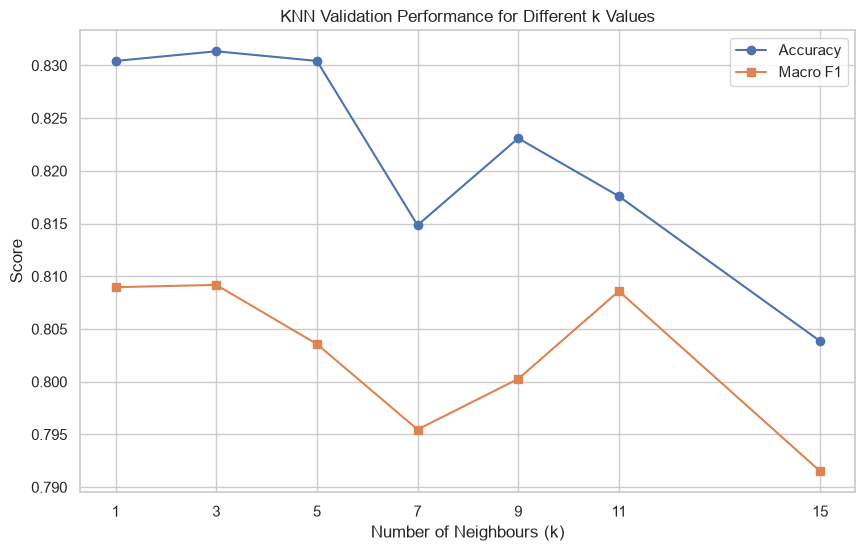

In [46]:
plt.figure(figsize=(10, 6))

plt.plot(
    knn_tuning_df["k"],
    knn_tuning_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    knn_tuning_df["k"],
    knn_tuning_df["Macro F1"],
    marker="s",
    label="Macro F1"
)

plt.title("KNN Validation Performance for Different k Values")
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Score")
plt.xticks(k_values)
plt.legend()

plt.show()

In [47]:
best_index = knn_tuning_df[
    "Macro F1"
].idxmax()

best_k = int(
    knn_tuning_df.loc[
        best_index,
        "k"
    ]
)

print(
    "Selected k:",
    best_k
)

print(
    "Best validation Macro F1:",
    knn_tuning_df.loc[
        best_index,
        "Macro F1"
    ]
)

Selected k: 3
Best validation Macro F1: 0.8091872934328412


In [48]:
knn_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "knn",
            KNeighborsClassifier(
                n_neighbors=best_k
            )
        )
    ]
)

knn_pipeline.fit(
    X_train,
    y_train
)

knn_val_pred = knn_pipeline.predict(
    X_val
)

knn_val_accuracy = accuracy_score(
    y_val,
    knn_val_pred
)

knn_val_macro_f1 = f1_score(
    y_val,
    knn_val_pred,
    average="macro"
)

print(
    "Selected KNN validation accuracy:",
    knn_val_accuracy
)

print(
    "Selected KNN validation Macro F1:",
    knn_val_macro_f1
)

Selected KNN validation accuracy: 0.8313473877176902
Selected KNN validation Macro F1: 0.8091872934328412


In [49]:
print(
    classification_report(
        y_val,
        knn_val_pred,
        zero_division=0
    )
)

                   precision    recall  f1-score   support

     Move-Forward       0.87      0.78      0.82       493
 Sharp-Right-Turn       0.87      0.87      0.87       446
 Slight-Left-Turn       0.73      0.92      0.81        38
Slight-Right-Turn       0.63      0.85      0.73       114

         accuracy                           0.83      1091
        macro avg       0.78      0.86      0.81      1091
     weighted avg       0.84      0.83      0.83      1091



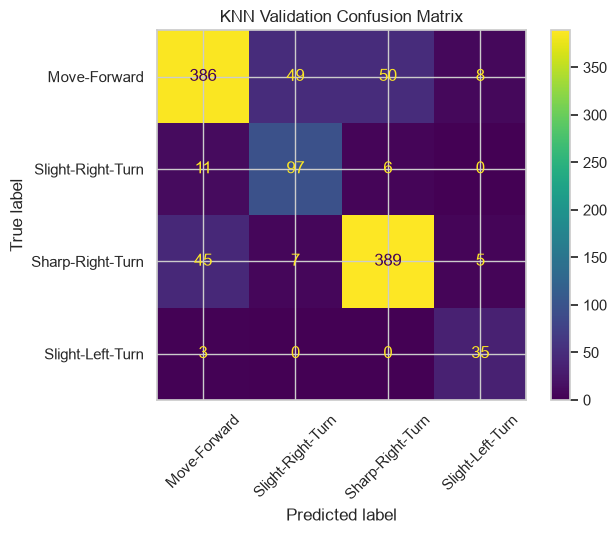

In [50]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    knn_val_pred,
    labels=expected_classes,
    xticks_rotation=45
)

plt.title(
    "KNN Validation Confusion Matrix"
)

plt.show()

In [51]:
model_comparison = pd.DataFrame(
    {
        "Model": [
            "Majority Baseline",
            "KNN"
        ],
        "Validation Accuracy": [
            baseline_accuracy,
            knn_val_accuracy
        ],
        "Validation Macro F1": [
            baseline_macro_f1,
            knn_val_macro_f1
        ]
    }
)

model_comparison

,Model,Validation Accuracy,Validation Macro F1
0,Majority Baseline,0.451879,0.155619
1,KNN,0.831347,0.809187


## 14. Baseline and KNN Validation Summary

The sequential dataset was divided without random shuffling into training, validation, and final test sets. The first 60% of observations are used for training, the next 20% for validation, and the final 20% is reserved for final testing.

The majority-class baseline always predicts `Move-Forward`. Although this produces some correct predictions because `Move-Forward` is common, the low Macro F1 score shows that the baseline performs poorly across the four navigation classes.

KNN substantially improves both validation accuracy and Macro F1 compared with the baseline. Because KNN is distance-based, the model is implemented using a pipeline containing `StandardScaler` followed by `KNeighborsClassifier`.

Several values of `k` are evaluated using validation data. The selected KNN configuration is determined using validation Macro F1 so that performance on smaller classes is considered rather than relying only on overall accuracy.

The final test set has not been used for model fitting, parameter selection, or validation. It remains untouched for the final evaluation after all candidate models have been compared.

## 15. Decision Tree Classification

A Decision Tree predicts a class by repeatedly dividing the data according to feature values.

Decision Trees are suitable for this project because the robot-navigation task contains nonlinear relationships between multiple numerical sensor readings and the navigation action.

Unlike KNN, a Decision Tree does not depend on distance calculations between observations. Therefore, feature scaling is not required for this model.

The same training and validation sets used for KNN are also used for the Decision Tree so that the candidate models can be compared fairly.

In [52]:
initial_decision_tree = DecisionTreeClassifier(
    random_state=42
)

initial_decision_tree.fit(
    X_train,
    y_train
)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [53]:
initial_dt_val_pred = initial_decision_tree.predict(
    X_val
)

initial_dt_accuracy = accuracy_score(
    y_val,
    initial_dt_val_pred
)

initial_dt_macro_f1 = f1_score(
    y_val,
    initial_dt_val_pred,
    average="macro"
)

print(
    "Initial Decision Tree validation accuracy:",
    initial_dt_accuracy
)

print(
    "Initial Decision Tree validation Macro F1:",
    initial_dt_macro_f1
)

Initial Decision Tree validation accuracy: 0.9908340971585701
Initial Decision Tree validation Macro F1: 0.9758029692686716


### Decision Tree Parameter Selection

The main Decision Tree parameter examined is `max_depth`.

`max_depth` controls how many levels the tree is allowed to grow.

A very shallow tree may be too simple to represent the navigation patterns, while an unnecessarily deep tree may become more complex than needed.

Several depth values are therefore compared using validation Macro F1. The final test set is not used during this selection.

In [54]:
dt_depth_values = [
    3,
    5,
    7,
    10,
    15,
    None
]

dt_tuning_results = []

for depth in dt_depth_values:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_val
    )

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    macro_f1 = f1_score(
        y_val,
        predictions,
        average="macro"
    )

    depth_label = (
        "None"
        if depth is None
        else str(depth)
    )

    dt_tuning_results.append(
        {
            "Max Depth": depth_label,
            "Accuracy": accuracy,
            "Macro F1": macro_f1
        }
    )

In [55]:
dt_tuning_df = pd.DataFrame(
    dt_tuning_results
)

dt_tuning_df

,Max Depth,Accuracy,Macro F1
0,3,0.930339,0.694702
1,5,0.960587,0.913771
2,7,0.990834,0.975803
3,10,0.990834,0.975803
4,15,0.990834,0.975803
5,None,0.990834,0.975803


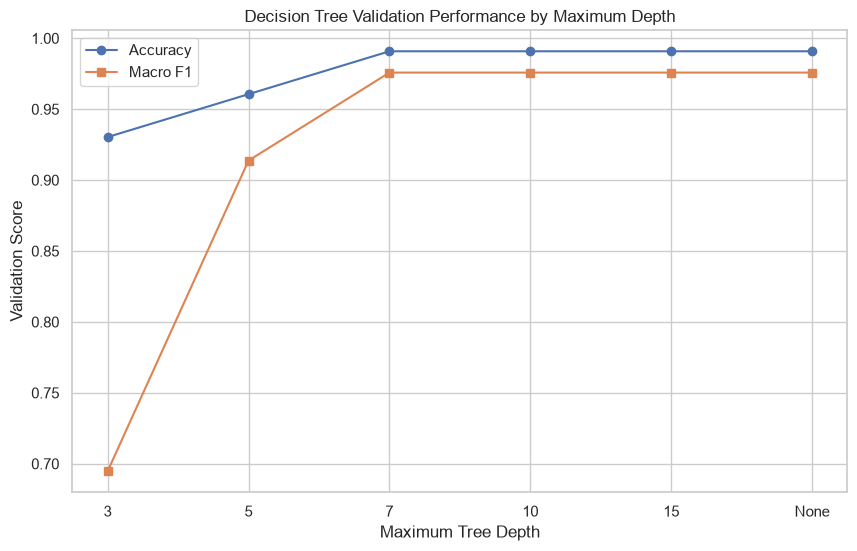

In [56]:
plt.figure(figsize=(10, 6))

plt.plot(
    dt_tuning_df["Max Depth"],
    dt_tuning_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    dt_tuning_df["Max Depth"],
    dt_tuning_df["Macro F1"],
    marker="s",
    label="Macro F1"
)

plt.title(
    "Decision Tree Validation Performance by Maximum Depth"
)

plt.xlabel(
    "Maximum Tree Depth"
)

plt.ylabel(
    "Validation Score"
)

plt.legend()

plt.show()

In [57]:
best_dt_index = dt_tuning_df[
    "Macro F1"
].idxmax()

best_dt_depth_label = dt_tuning_df.loc[
    best_dt_index,
    "Max Depth"
]

if best_dt_depth_label == "None":
    best_dt_depth = None
else:
    best_dt_depth = int(
        best_dt_depth_label
    )

print(
    "Selected Decision Tree max_depth:",
    best_dt_depth
)

print(
    "Best Decision Tree validation Macro F1:",
    dt_tuning_df.loc[
        best_dt_index,
        "Macro F1"
    ]
)

Selected Decision Tree max_depth: 7
Best Decision Tree validation Macro F1: 0.9758029692686716


In [58]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=best_dt_depth,
    random_state=42
)

decision_tree_model.fit(
    X_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [59]:
decision_tree_val_pred = (
    decision_tree_model.predict(
        X_val
    )
)

decision_tree_val_accuracy = (
    accuracy_score(
        y_val,
        decision_tree_val_pred
    )
)

decision_tree_val_macro_f1 = (
    f1_score(
        y_val,
        decision_tree_val_pred,
        average="macro"
    )
)

print(
    "Decision Tree validation accuracy:",
    decision_tree_val_accuracy
)

print(
    "Decision Tree validation Macro F1:",
    decision_tree_val_macro_f1
)

Decision Tree validation accuracy: 0.9908340971585701
Decision Tree validation Macro F1: 0.9758029692686716


In [60]:
print(
    classification_report(
        y_val,
        decision_tree_val_pred,
        zero_division=0
    )
)

                   precision    recall  f1-score   support

     Move-Forward       1.00      0.99      0.99       493
 Sharp-Right-Turn       1.00      1.00      1.00       446
 Slight-Left-Turn       0.92      0.95      0.94        38
Slight-Right-Turn       0.96      1.00      0.98       114

         accuracy                           0.99      1091
        macro avg       0.97      0.98      0.98      1091
     weighted avg       0.99      0.99      0.99      1091



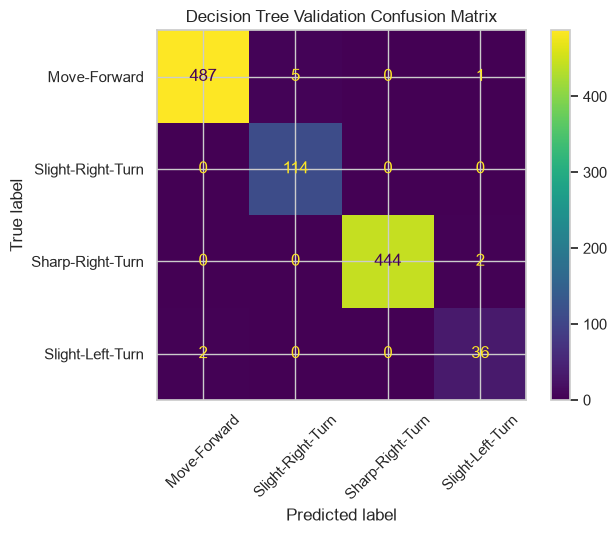

In [61]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    decision_tree_val_pred,
    labels=expected_classes,
    xticks_rotation=45
)

plt.title(
    "Decision Tree Validation Confusion Matrix"
)

plt.show()

### Decision Tree Validation Interpretation

The Decision Tree achieves strong validation performance on the robot-navigation classification task.

The depth experiment shows that very shallow trees are not sufficiently flexible for the sensor relationships, while performance improves considerably as the allowed tree depth increases.

The selected depth provides strong validation Accuracy and Macro F1 without requiring a deeper tree when the validation score does not meaningfully improve.

The Decision Tree does not require feature scaling, but it uses exactly the same training and validation observations and the same evaluation metrics as the other candidate models.

## 16. Random Forest Classification

Random Forest combines predictions from multiple Decision Trees rather than relying on only one tree.

Each tree is trained using variation in the training data and features, and the forest combines their predictions to determine the final class.

Random Forest is suitable for this project because it can model nonlinear relationships and interactions among the 24 numerical ultrasonic sensor readings.

Like the Decision Tree, Random Forest does not require feature scaling. The original numerical features and the same training and validation sets are therefore used.

In [62]:
initial_random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

initial_random_forest.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [63]:
initial_rf_val_pred = (
    initial_random_forest.predict(
        X_val
    )
)

initial_rf_accuracy = (
    accuracy_score(
        y_val,
        initial_rf_val_pred
    )
)

initial_rf_macro_f1 = (
    f1_score(
        y_val,
        initial_rf_val_pred,
        average="macro"
    )
)

print(
    "Initial Random Forest validation accuracy:",
    initial_rf_accuracy
)

print(
    "Initial Random Forest validation Macro F1:",
    initial_rf_macro_f1
)

Initial Random Forest validation accuracy: 0.9917506874427131
Initial Random Forest validation Macro F1: 0.9747274931525614


### Random Forest Parameter Selection

Two understandable Random Forest parameters are examined:

- `max_depth`: controls the maximum depth of each tree.
- `n_estimators`: controls how many trees are included in the forest.

The parameters are selected using validation Macro F1. The final test set remains untouched.

In [64]:
rf_depth_values = [
    5,
    7,
    10,
    15,
    None
]

rf_depth_results = []

for depth in rf_depth_values:

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_val
    )

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    macro_f1 = f1_score(
        y_val,
        predictions,
        average="macro"
    )

    depth_label = (
        "None"
        if depth is None
        else str(depth)
    )

    rf_depth_results.append(
        {
            "Max Depth": depth_label,
            "Accuracy": accuracy,
            "Macro F1": macro_f1
        }
    )

In [65]:
rf_depth_df = pd.DataFrame(
    rf_depth_results
)

rf_depth_df

,Max Depth,Accuracy,Macro F1
0,5,0.974335,0.943522
1,7,0.991751,0.976734
2,10,0.994500,0.984958
3,15,0.992667,0.978483
4,None,0.991751,0.974727


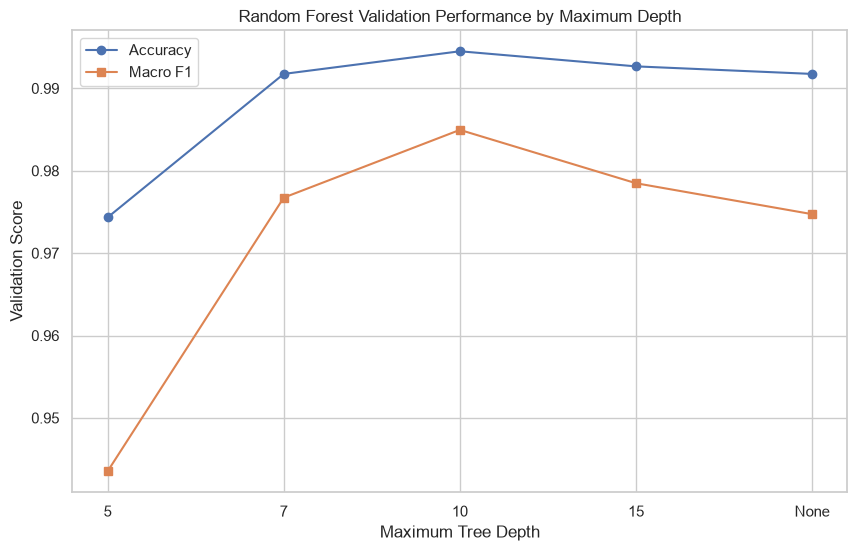

In [66]:
plt.figure(figsize=(10, 6))

plt.plot(
    rf_depth_df["Max Depth"],
    rf_depth_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    rf_depth_df["Max Depth"],
    rf_depth_df["Macro F1"],
    marker="s",
    label="Macro F1"
)

plt.title(
    "Random Forest Validation Performance by Maximum Depth"
)

plt.xlabel(
    "Maximum Tree Depth"
)

plt.ylabel(
    "Validation Score"
)

plt.legend()

plt.show()

In [67]:
best_rf_depth_index = rf_depth_df[
    "Macro F1"
].idxmax()

best_rf_depth_label = rf_depth_df.loc[
    best_rf_depth_index,
    "Max Depth"
]

if best_rf_depth_label == "None":
    best_rf_depth = None
else:
    best_rf_depth = int(
        best_rf_depth_label
    )

print(
    "Selected Random Forest max_depth:",
    best_rf_depth
)

print(
    "Best depth validation Macro F1:",
    rf_depth_df.loc[
        best_rf_depth_index,
        "Macro F1"
    ]
)

Selected Random Forest max_depth: 10
Best depth validation Macro F1: 0.9849579759760648


In [68]:
rf_tree_counts = [
    50,
    100,
    150,
    200
]

rf_tree_results = []

for tree_count in rf_tree_counts:

    model = RandomForestClassifier(
        n_estimators=tree_count,
        max_depth=best_rf_depth,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_val
    )

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    macro_f1 = f1_score(
        y_val,
        predictions,
        average="macro"
    )

    rf_tree_results.append(
        {
            "Number of Trees": tree_count,
            "Accuracy": accuracy,
            "Macro F1": macro_f1
        }
    )

In [69]:
rf_tree_df = pd.DataFrame(
    rf_tree_results
)

rf_tree_df

,Number of Trees,Accuracy,Macro F1
0,50,0.993584,0.979383
1,100,0.994500,0.984958
2,150,0.994500,0.984958
3,200,0.994500,0.982791


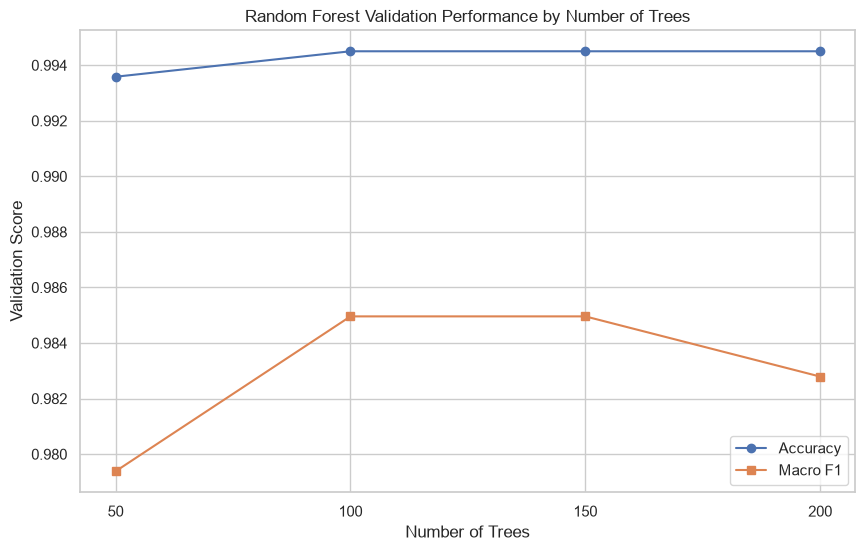

In [70]:
plt.figure(figsize=(10, 6))

plt.plot(
    rf_tree_df["Number of Trees"],
    rf_tree_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    rf_tree_df["Number of Trees"],
    rf_tree_df["Macro F1"],
    marker="s",
    label="Macro F1"
)

plt.title(
    "Random Forest Validation Performance by Number of Trees"
)

plt.xlabel(
    "Number of Trees"
)

plt.ylabel(
    "Validation Score"
)

plt.xticks(
    rf_tree_counts
)

plt.legend()

plt.show()

In [71]:
best_rf_tree_index = rf_tree_df[
    "Macro F1"
].idxmax()

best_rf_n_estimators = int(
    rf_tree_df.loc[
        best_rf_tree_index,
        "Number of Trees"
    ]
)

print(
    "Selected Random Forest n_estimators:",
    best_rf_n_estimators
)

Selected Random Forest n_estimators: 100


In [72]:
random_forest_model = RandomForestClassifier(
    n_estimators=best_rf_n_estimators,
    max_depth=best_rf_depth,
    random_state=42
)

random_forest_model.fit(
    X_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [73]:
random_forest_val_pred = (
    random_forest_model.predict(
        X_val
    )
)

random_forest_val_accuracy = (
    accuracy_score(
        y_val,
        random_forest_val_pred
    )
)

random_forest_val_macro_f1 = (
    f1_score(
        y_val,
        random_forest_val_pred,
        average="macro"
    )
)

print(
    "Random Forest validation accuracy:",
    random_forest_val_accuracy
)

print(
    "Random Forest validation Macro F1:",
    random_forest_val_macro_f1
)

Random Forest validation accuracy: 0.9945004582951421
Random Forest validation Macro F1: 0.9849579759760648


In [74]:
print(
    classification_report(
        y_val,
        random_forest_val_pred,
        zero_division=0
    )
)

                   precision    recall  f1-score   support

     Move-Forward       0.99      0.99      0.99       493
 Sharp-Right-Turn       1.00      1.00      1.00       446
 Slight-Left-Turn       1.00      0.92      0.96        38
Slight-Right-Turn       0.97      1.00      0.99       114

         accuracy                           0.99      1091
        macro avg       0.99      0.98      0.98      1091
     weighted avg       0.99      0.99      0.99      1091



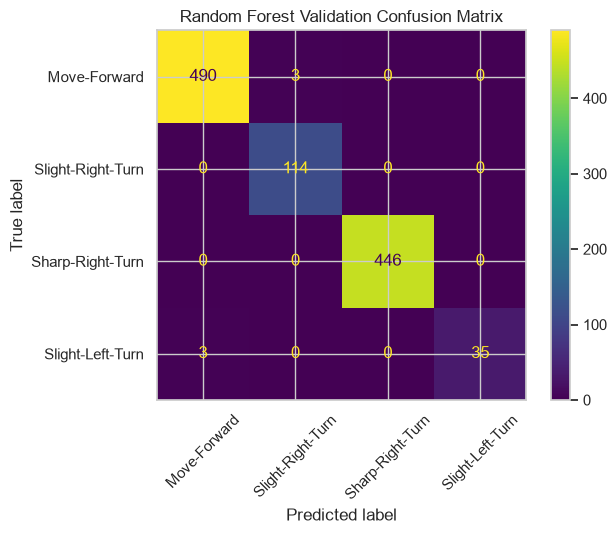

In [75]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    random_forest_val_pred,
    labels=expected_classes,
    xticks_rotation=45
)

plt.title(
    "Random Forest Validation Confusion Matrix"
)

plt.show()

## 17. Tree-Based Model Validation Summary

Decision Tree and Random Forest models have been trained using the same training observations and evaluated using the same validation observations used for the previous candidate model.

Decision Tree depth was selected using validation Macro F1. The depth experiment shows that shallow trees are less effective for the navigation data, while a moderately deeper tree captures the sensor relationships substantially better.

Random Forest was evaluated using different maximum depths and numbers of trees. Its selected configuration is based on validation Macro F1 rather than the final test set.

Both tree-based models achieve strong validation performance and provide additional candidate models for the final comparison stage.

No feature scaling was applied to the tree-based models because they do not rely on distance calculations.

The final test set remains untouched. No test predictions, test accuracy, test Macro F1, or test confusion matrix have been calculated at this stage.

## 18. Candidate Model Comparison

All candidate models are compared using the same validation observations and consistent classification metrics.

Macro-averaged Precision, Recall, and F1 are included because the navigation classes are imbalanced. Macro averaging gives equal importance to each navigation class.

The final model is selected using validation results only. The final test set is not used during model selection.

In [76]:
baseline_macro_precision = precision_score(
    y_val,
    baseline_val_pred,
    average="macro",
    zero_division=0
)

baseline_macro_recall = recall_score(
    y_val,
    baseline_val_pred,
    average="macro",
    zero_division=0
)

print("Baseline Macro Precision:", baseline_macro_precision)
print("Baseline Macro Recall:", baseline_macro_recall)

Baseline Macro Precision: 0.11296975252062329
Baseline Macro Recall: 0.25


In [77]:
knn_val_macro_precision = precision_score(
    y_val,
    knn_val_pred,
    average="macro",
    zero_division=0
)

knn_val_macro_recall = recall_score(
    y_val,
    knn_val_pred,
    average="macro",
    zero_division=0
)

print("KNN Macro Precision:", knn_val_macro_precision)
print("KNN Macro Recall:", knn_val_macro_recall)

KNN Macro Precision: 0.7761816571197767
KNN Macro Recall: 0.8567721486061728


In [78]:
decision_tree_val_macro_precision = precision_score(
    y_val,
    decision_tree_val_pred,
    average="macro",
    zero_division=0
)

decision_tree_val_macro_recall = recall_score(
    y_val,
    decision_tree_val_pred,
    average="macro",
    zero_division=0
)

random_forest_val_macro_precision = precision_score(
    y_val,
    random_forest_val_pred,
    average="macro",
    zero_division=0
)

random_forest_val_macro_recall = recall_score(
    y_val,
    random_forest_val_pred,
    average="macro",
    zero_division=0
)

print(
    "Decision Tree Macro Precision:",
    decision_tree_val_macro_precision
)

print(
    "Decision Tree Macro Recall:",
    decision_tree_val_macro_recall
)

print(
    "Random Forest Macro Precision:",
    random_forest_val_macro_precision
)

print(
    "Random Forest Macro Recall:",
    random_forest_val_macro_recall
)

Decision Tree Macro Precision: 0.9692425342010329
Decision Tree Macro Recall: 0.9826784326810897
Random Forest Macro Precision: 0.9920684454153015
Random Forest Macro Recall: 0.9787418597202946


In [79]:
full_model_comparison = pd.DataFrame(
    {
        "Model": [
            "Majority Baseline",
            "KNN",
            "Decision Tree",
            "Random Forest"
        ],
        "Validation Accuracy": [
            baseline_accuracy,
            knn_val_accuracy,
            decision_tree_val_accuracy,
            random_forest_val_accuracy
        ],
        "Macro Precision": [
            baseline_macro_precision,
            knn_val_macro_precision,
            decision_tree_val_macro_precision,
            random_forest_val_macro_precision
        ],
        "Macro Recall": [
            baseline_macro_recall,
            knn_val_macro_recall,
            decision_tree_val_macro_recall,
            random_forest_val_macro_recall
        ],
        "Macro F1": [
            baseline_macro_f1,
            knn_val_macro_f1,
            decision_tree_val_macro_f1,
            random_forest_val_macro_f1
        ]
    }
)

full_model_comparison

,Model,Validation Accuracy,Macro Precision,Macro Recall,Macro F1
0,Majority Baseline,0.451879,0.112970,0.250000,0.155619
1,KNN,0.831347,0.776182,0.856772,0.809187
2,Decision Tree,0.990834,0.969243,0.982678,0.975803
3,Random Forest,0.994500,0.992068,0.978742,0.984958


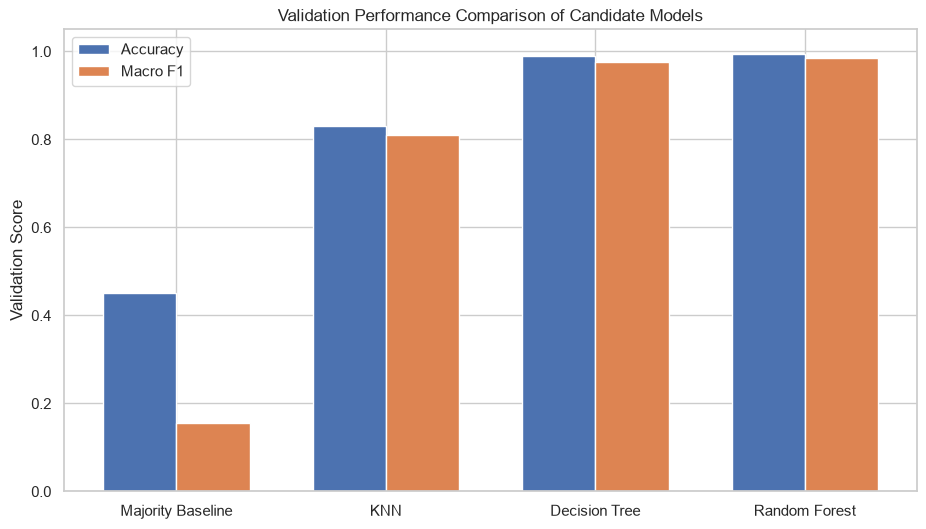

In [80]:
x_positions = np.arange(
    len(full_model_comparison)
)

bar_width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x_positions - bar_width / 2,
    full_model_comparison[
        "Validation Accuracy"
    ],
    width=bar_width,
    label="Accuracy"
)

plt.bar(
    x_positions + bar_width / 2,
    full_model_comparison[
        "Macro F1"
    ],
    width=bar_width,
    label="Macro F1"
)

plt.xticks(
    x_positions,
    full_model_comparison["Model"]
)

plt.ylabel("Validation Score")

plt.title(
    "Validation Performance Comparison of Candidate Models"
)

plt.ylim(0, 1.05)

plt.legend()

plt.show()

### Computational Cost Comparison

In addition to predictive performance, training and validation prediction time are recorded for the three machine-learning models.

Timing measurements may vary slightly between computers and runs. They are therefore used as approximate computational evidence rather than as an exact performance ranking.

In [81]:
timing_knn = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "knn",
            KNeighborsClassifier(
                n_neighbors=best_k
            )
        )
    ]
)

start_time = perf_counter()

timing_knn.fit(
    X_train,
    y_train
)

knn_training_time = (
    perf_counter() - start_time
)

start_time = perf_counter()

timing_knn.predict(
    X_val
)

knn_prediction_time = (
    perf_counter() - start_time
)

print(
    "KNN training time:",
    knn_training_time
)

print(
    "KNN validation prediction time:",
    knn_prediction_time
)

KNN training time: 0.04610010000033071
KNN validation prediction time: 0.0603904000017792


In [82]:
timing_decision_tree = DecisionTreeClassifier(
    max_depth=best_dt_depth,
    random_state=42
)

start_time = perf_counter()

timing_decision_tree.fit(
    X_train,
    y_train
)

decision_tree_training_time = (
    perf_counter() - start_time
)

start_time = perf_counter()

timing_decision_tree.predict(
    X_val
)

decision_tree_prediction_time = (
    perf_counter() - start_time
)

print(
    "Decision Tree training time:",
    decision_tree_training_time
)

print(
    "Decision Tree validation prediction time:",
    decision_tree_prediction_time
)

Decision Tree training time: 0.10627129999920726
Decision Tree validation prediction time: 0.00523599999723956


In [83]:
timing_random_forest = RandomForestClassifier(
    n_estimators=best_rf_n_estimators,
    max_depth=best_rf_depth,
    random_state=42
)

start_time = perf_counter()

timing_random_forest.fit(
    X_train,
    y_train
)

random_forest_training_time = (
    perf_counter() - start_time
)

start_time = perf_counter()

timing_random_forest.predict(
    X_val
)

random_forest_prediction_time = (
    perf_counter() - start_time
)

print(
    "Random Forest training time:",
    random_forest_training_time
)

print(
    "Random Forest validation prediction time:",
    random_forest_prediction_time
)

Random Forest training time: 1.57994840000174
Random Forest validation prediction time: 0.03475349999644095


In [84]:
computational_cost = pd.DataFrame(
    {
        "Model": [
            "KNN",
            "Decision Tree",
            "Random Forest"
        ],
        "Training Time (seconds)": [
            knn_training_time,
            decision_tree_training_time,
            random_forest_training_time
        ],
        "Prediction Time (seconds)": [
            knn_prediction_time,
            decision_tree_prediction_time,
            random_forest_prediction_time
        ]
    }
)

computational_cost

,Model,Training Time (seconds),Prediction Time (seconds)
0,KNN,0.046100,0.060390
1,Decision Tree,0.106271,0.005236
2,Random Forest,1.579948,0.034753


In [85]:
candidate_models = full_model_comparison[
    full_model_comparison["Model"]
    != "Majority Baseline"
].copy()

candidate_models

,Model,Validation Accuracy,Macro Precision,Macro Recall,Macro F1
1,KNN,0.831347,0.776182,0.856772,0.809187
2,Decision Tree,0.990834,0.969243,0.982678,0.975803
3,Random Forest,0.994500,0.992068,0.978742,0.984958


In [86]:
selected_model_row = (
    candidate_models
    .sort_values(
        by=[
            "Macro F1",
            "Validation Accuracy"
        ],
        ascending=False
    )
    .iloc[0]
)

selected_model_name = (
    selected_model_row["Model"]
)

print(
    "Selected final model:",
    selected_model_name
)

print(
    "Selected model validation Macro F1:",
    selected_model_row["Macro F1"]
)

Selected final model: Random Forest
Selected model validation Macro F1: 0.9849579759760648


### Final Model Selection

The final model is selected before examining final test performance.

Validation Macro F1 is used as the primary selection metric because the navigation classes are imbalanced. Validation Accuracy is considered as supporting evidence.

Among the candidate models, Random Forest provides the strongest validation Macro F1 with very high validation accuracy. Therefore, its selected hyperparameters are locked before final test evaluation.

The final test set has not influenced model selection or hyperparameter tuning.

## 19. Final Model Training and Test Evaluation

After the model type and hyperparameters are locked using validation results, the selected model is retrained using the complete development dataset.

The development dataset contains the original training and validation observations but excludes the final test set.

The test set is then used only for the final evaluation.

In [87]:
if selected_model_name == "KNN":

    final_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "knn",
                KNeighborsClassifier(
                    n_neighbors=best_k
                )
            )
        ]
    )

elif selected_model_name == "Decision Tree":

    final_model = DecisionTreeClassifier(
        max_depth=best_dt_depth,
        random_state=42
    )

elif selected_model_name == "Random Forest":

    final_model = RandomForestClassifier(
        n_estimators=best_rf_n_estimators,
        max_depth=best_rf_depth,
        random_state=42
    )

final_model.fit(
    X_dev,
    y_dev
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [88]:
final_test_pred = final_model.predict(
    X_test
)

print(
    "Number of final test predictions:",
    len(final_test_pred)
)

Number of final test predictions: 1092


In [89]:
final_test_accuracy = accuracy_score(
    y_test,
    final_test_pred
)

final_test_macro_precision = precision_score(
    y_test,
    final_test_pred,
    average="macro",
    zero_division=0
)

final_test_macro_recall = recall_score(
    y_test,
    final_test_pred,
    average="macro",
    zero_division=0
)

final_test_macro_f1 = f1_score(
    y_test,
    final_test_pred,
    average="macro",
    zero_division=0
)

print(
    "Final test accuracy:",
    final_test_accuracy
)

print(
    "Final test Macro Precision:",
    final_test_macro_precision
)

print(
    "Final test Macro Recall:",
    final_test_macro_recall
)

print(
    "Final test Macro F1:",
    final_test_macro_f1
)

Final test accuracy: 0.9853479853479854
Final test Macro Precision: 0.9842587305296137
Final test Macro Recall: 0.9836611986144697
Final test Macro F1: 0.9837166648642913


In [90]:
final_classification_report = (
    classification_report(
        y_test,
        final_test_pred,
        zero_division=0
    )
)

print(
    final_classification_report
)

                   precision    recall  f1-score   support

     Move-Forward       1.00      0.97      0.98       429
 Sharp-Right-Turn       0.98      1.00      0.99       408
 Slight-Left-Turn       1.00      0.96      0.98       107
Slight-Right-Turn       0.96      1.00      0.98       148

         accuracy                           0.99      1092
        macro avg       0.98      0.98      0.98      1092
     weighted avg       0.99      0.99      0.99      1092



In [91]:
final_report_df = pd.DataFrame(
    classification_report(
        y_test,
        final_test_pred,
        output_dict=True,
        zero_division=0
    )
).transpose()

final_report_df

,precision,recall,f1-score,support
Move-Forward,0.995227,0.972028,0.983491,429.000000
Sharp-Right-Turn,0.980769,1.000000,0.990291,408.000000
Slight-Left-Turn,1.000000,0.962617,0.980952,107.000000
Slight-Right-Turn,0.961039,1.000000,0.980132,148.000000
accuracy,0.985348,0.985348,0.985348,0.985348
macro avg,0.984259,0.983661,0.983717,1092.000000
weighted avg,0.985659,0.985348,0.985328,1092.000000


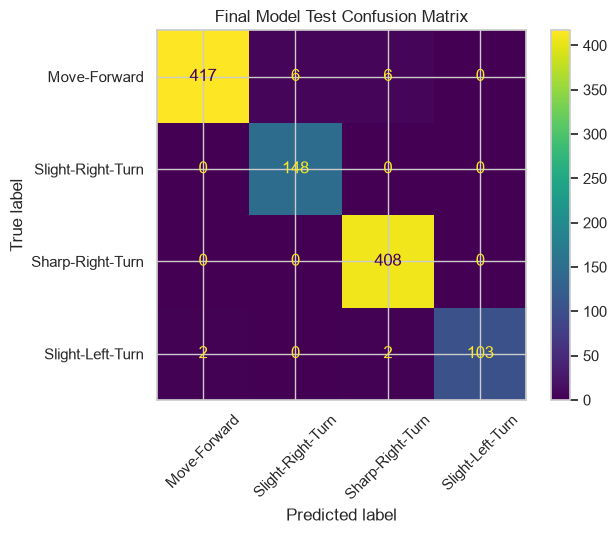

In [92]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_test_pred,
    labels=expected_classes,
    xticks_rotation=45
)

plt.title(
    "Final Model Test Confusion Matrix"
)

plt.show()

## 20. Final Error Analysis

Final test errors are examined to identify which navigation actions are most commonly confused.

This analysis is performed after the model and hyperparameters have already been locked. The test results are not used to modify the model.

In [93]:
test_results = pd.DataFrame(
    {
        "Actual": y_test.to_numpy(),
        "Predicted": final_test_pred
    }
)

test_errors = test_results[
    test_results["Actual"]
    != test_results["Predicted"]
].copy()

print(
    "Total test observations:",
    len(test_results)
)

print(
    "Incorrect predictions:",
    len(test_errors)
)

print(
    "Correct predictions:",
    len(test_results) - len(test_errors)
)

Total test observations: 1092
Incorrect predictions: 16
Correct predictions: 1076


In [94]:
test_error_rate = (
    len(test_errors)
    / len(test_results)
)

print(
    "Final test error rate:",
    test_error_rate
)

print(
    "Final test error rate (%):",
    test_error_rate * 100
)

Final test error rate: 0.014652014652014652
Final test error rate (%): 1.465201465201465


In [95]:
error_pairs = (
    test_errors
    .groupby(
        [
            "Actual",
            "Predicted"
        ]
    )
    .size()
    .reset_index(
        name="Count"
    )
    .sort_values(
        by="Count",
        ascending=False
    )
)

error_pairs

,Actual,Predicted,Count
0,Move-Forward,Sharp-Right-Turn,6
1,Move-Forward,Slight-Right-Turn,6
2,Slight-Left-Turn,Move-Forward,2
3,Slight-Left-Turn,Sharp-Right-Turn,2


### Error Analysis Interpretation

The selected model correctly classifies the large majority of final test observations.

The remaining errors are concentrated in a small number of navigation-action pairs. Most errors involve `Move-Forward` being confused with a right-turn action, while a smaller number involve `Slight-Left-Turn`.

This is reasonable because neighbouring navigation actions may occur under sensor configurations with similar distance patterns. The error analysis therefore suggests that the remaining mistakes are concentrated near movement boundaries rather than being evenly distributed across all classes.

The strong overall result should still be interpreted with caution. The dataset was collected from one robot performing wall-following navigation in a particular environment, so high performance on this dataset does not guarantee equivalent performance in different rooms, with different obstacles, sensors, robots, or environmental conditions.

## 21. Assumptions and Limitations

Several limitations should be considered when interpreting the results:

- The dataset contains sequential observations collected during four navigation rounds.
- Explicit round identifiers are not included in the selected data file, so an ordered 60/20/20 split is used instead of a true round-based group split.
- Consecutive sensor observations may still be correlated because measurements were recorded at a high sampling rate.
- The dataset represents wall-following behaviour in a specific experimental setting and may not represent all mobile-robot environments.
- Class frequencies are imbalanced, although Macro F1 and class-wise metrics are used to reduce reliance on overall accuracy.
- Sensor noise, hardware differences, new obstacle layouts, and environmental changes could reduce performance on new data.
- The results demonstrate classification performance on this dataset and should not be interpreted as proof that the model is safe for unrestricted real-world autonomous control.

### Responsible Use

The trained classifier should be treated as an experimental navigation-action predictor rather than a complete safety-critical robot controller.

Deployment in a real robot would require additional testing with unseen environments, obstacle configurations, sensor failures, hardware variation, and appropriate safety mechanisms.

## 22. Reproducibility Information

In [96]:
print(
    "Python version:",
    sys.version.split()[0]
)

packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "jupyter"
]

for package in packages:

    print(
        package,
        metadata.version(package)
    )

Python version: 3.13.14
numpy 2.5.3
pandas 3.0.5
matplotlib 3.11.1
seaborn 0.13.2
scikit-learn 1.9.0
jupyter 1.1.1



## Final Model

The validation comparison selects Random Forest as the strongest candidate model.

Selected configuration:

- `n_estimators = 100`
- `max_depth = 10`
- `random_state = 42`

The final model is retrained using the complete development dataset before evaluation on the untouched final test set.

## 23. Conclusion

This project developed and evaluated machine-learning models for predicting mobile-robot navigation actions from 24 ultrasonic sensor readings.

A majority-class baseline was first established, followed by K-Nearest Neighbours, Decision Tree, and Random Forest classifiers. All candidate models were evaluated using the same ordered training and validation sets, while the final test set remained untouched during model development and parameter selection.

KNN substantially improved upon the baseline, while the tree-based models achieved considerably stronger validation performance. Random Forest obtained the strongest validation Macro F1 among the tested candidate models and was therefore selected for final evaluation.

After the model configuration was locked, Random Forest was retrained using the complete development dataset and evaluated on the final test set. The final model achieved approximately 98.5% test accuracy and a Macro F1 of approximately 0.984, with only a small number of misclassified observations.

Although the results are strong, they are specific to the available wall-following robot dataset. Further evaluation using different environments, navigation runs, sensor conditions, and robots would be necessary before considering real-world deployment.